In [1]:
import sys
sys.path.append('../')
from core import LSTransferTreeBoost
import pandas as pd
import numpy as np
from utils import * #only needed for xgboost

from friedman1 import *

In [27]:
X_target_train, y_target_train = friedman1(n_samples=100, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=1) #add noise to train set
X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'gaussian',
                                                n_features=10, d=100, shift_seed=1, random_seed = 1) #also add noise to source (only train here)

average_magnitude_hat = []
average_magnitude = []

fiter = LSTransferTreeBoost(epochs=100, v=0.1, source_tree_size=2, 
                        target_tree_size=2, k=0.0, m_0=0.5)
leaf_gammas_tray, leaf_gammashats_tray, model_tray_clf, model_tray_clfhat, alpha_tray = fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
for gammahats in leaf_gammashats_tray:
    average_magnitude_hat.append(np.mean([np.abs(elem) for elem in gammahats]))
for gammas in leaf_gammas_tray:
    average_magnitude.append(np.mean([np.abs(elem) for elem in gammas]))

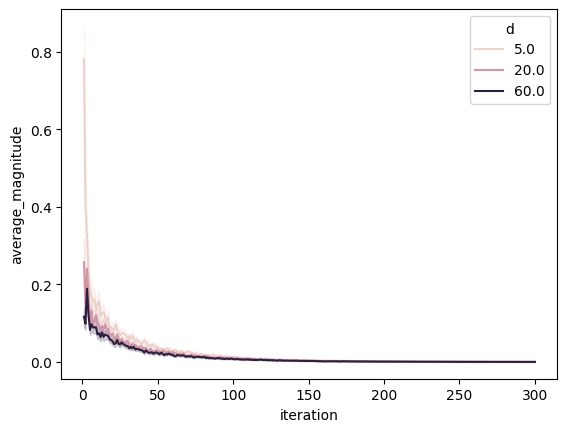

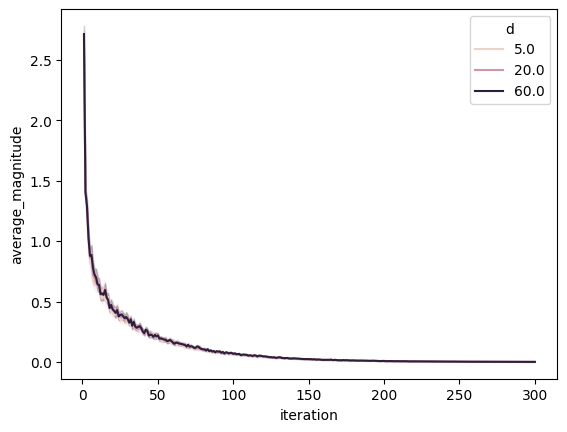

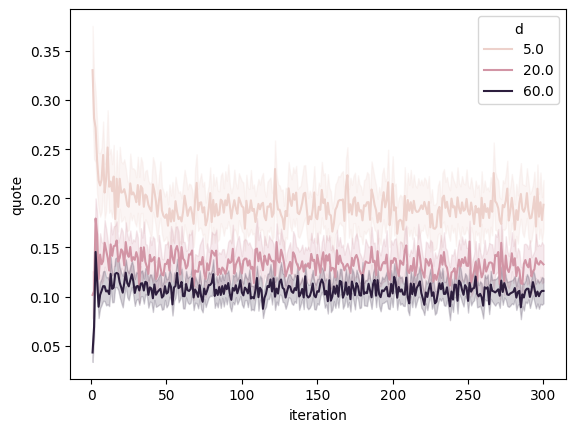

In [67]:
df_hat = pd.DataFrame(columns = ['iteration', 'average_magnitude', 'd'])
df = pd.DataFrame(columns = ['iteration', 'average_magnitude', 'd'])
d_list = [5, 20, 60]
for i in range(100):
    X_target_train, y_target_train = friedman1(n_samples=300, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=i) #add noise to train set
    for d in d_list:
        X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = False, noise_distribution = 'gaussian',
                                                        n_features=10, d=d, shift_seed=i, random_seed = i) #also add noise to source (only train here)

        average_magnitude_hat = []
        average_magnitude = []

        fiter = LSTransferTreeBoost(epochs=300, v=2.0, source_tree_size=2, 
                                target_tree_size=2, k=0.0, m_0=0.5)
        leaf_gammas_tray, leaf_gammashats_tray, model_tray_clf, model_tray_clfhat, alpha_tray = fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
        iteration = 1
        for gammahats in leaf_gammashats_tray:
            average_magnitude_hat = np.mean([np.abs(elem) for elem in gammahats])
            df_hat.loc[len(df_hat)] = [iteration, average_magnitude_hat, d]
            iteration += 1
        iteration = 1
        for gammas in leaf_gammas_tray:
            average_magnitude = np.mean([np.abs(elem) for elem in gammas])
            df.loc[len(df)] = [iteration, average_magnitude, d]
            iteration += 1
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data = df_hat, x = 'iteration', y = 'average_magnitude', hue = 'd')
plt.show()
sns.lineplot(data = df, x = 'iteration', y = 'average_magnitude', hue = 'd')
plt.show()
df_hat['quote'] = df_hat['average_magnitude'] / df['average_magnitude']
sns.lineplot(data = df_hat, x = 'iteration', y = 'quote', hue = 'd')
plt.show()

